# Experimentos CNN – Clasificación de Frutas
Dataset: Fruits-360 (10 clases) | Autor: David Velasco

4 variaciones del modelo base. Todos los entrenamientos corren en **GPU**.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import os


## Configuración GPU

In [2]:
# Configurar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU detectada: {gpus}')
        print('Dispositivo activo:', tf.test.gpu_device_name())
    except RuntimeError as e:
        print(e)
else:
    print('ADVERTENCIA: No se detectó GPU, usando CPU')


ADVERTENCIA: No se detectó GPU, usando CPU


## Carga de datos

In [3]:
import warnings; warnings.filterwarnings('ignore')

base_dir   = '../data/selected'  # ajusta si es necesario
train_dir  = os.path.join(base_dir, 'train')
test_dir   = os.path.join(base_dir, 'test')
img_size   = (128, 128)
batch_size = 32
val_split  = 0.2

base_datagen = ImageDataGenerator(rescale=1./255, validation_split=val_split)
test_datagen = ImageDataGenerator(rescale=1./255)

def make_generators(datagen):
    train = datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='training', shuffle=True
    )
    val = datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='validation', shuffle=True
    )
    return train, val

train_data, val_data = make_generators(base_datagen)

test_data = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

num_classes  = train_data.num_classes
class_labels = list(train_data.class_indices.keys())
print('Clases:', train_data.class_indices)
print('Num clases:', num_classes)


Found 3914 images belonging to 10 classes.
Found 975 images belonging to 10 classes.
Found 1638 images belonging to 10 classes.
Clases: {'Apple Golden 1': 0, 'Apple Red 1': 1, 'Banana 1': 2, 'Grape White 1': 3, 'Lemon 1': 4, 'Mango 1': 5, 'Orange 1': 6, 'Peach 1': 7, 'Pear 1': 8, 'Strawberry 1': 9}
Num clases: 10


## Función de evaluación compartida

In [4]:
def evaluar_modelo(model, history, test_data, class_labels, nombre_variacion='', training_time=None):
    test_loss, test_acc = model.evaluate(test_data, verbose=0)
    predictions = model.predict(test_data, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_data.classes

    optimizer      = model.optimizer
    learning_rate  = float(optimizer.learning_rate)
    optimizer_name = optimizer.__class__.__name__
    dropout_rate   = None
    l2_value       = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dropout):
            dropout_rate = layer.rate
        if hasattr(layer, 'kernel_regularizer') and layer.kernel_regularizer is not None:
            l2_value = layer.kernel_regularizer.l2

    sep = '=' * 50
    print(sep)
    print(f'{nombre_variacion:^50}')
    print(sep)
    print(f"{'Accuracy (test):':<25} {test_acc:.4f}")
    print(f"{'Loss (test):':<25} {test_loss:.4f}")
    print(f"{'Val Accuracy:':<25} {history.history['val_accuracy'][-1]:.4f}")
    print(f"{'Val Loss:':<25} {history.history['val_loss'][-1]:.4f}")
    if training_time:
        print(f"{'Tiempo entreno:':<25} {training_time:.2f}s")
    print('-' * 50)
    print(f"{'HIPERPARÁMETROS':^50}")
    print('-' * 50)
    print(f"{'Batch Size:':<25} {test_data.batch_size}")
    print(f"{'Learning Rate:':<25} {learning_rate}")
    print(f"{'Optimizer:':<25} {optimizer_name}")
    print(f"{'Regularización L2:':<25} {l2_value}")
    print(f"{'Dropout:':<25} {dropout_rate}")
    print(sep)

    print('\nReporte de clasificación:')
    print(classification_report(y_true, y_pred, target_names=class_labels))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicción'); plt.ylabel('Real')
    plt.title(f'Matriz de Confusión – {nombre_variacion}')
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'Accuracy – {nombre_variacion}'); axes[0].legend()
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'Loss – {nombre_variacion}'); axes[1].legend()
    plt.tight_layout(); plt.show()


## Variación 1 – Más profundidad convolucional
3 bloques Conv2D (32→64→128) + Dense 256 | 20 épocas | LR 0.001

In [5]:
import warnings; warnings.filterwarnings('ignore')

with tf.device('/GPU:0'):
    model_v1 = models.Sequential([
        layers.Input(shape=(128, 128, 3)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ])
    model_v1.summary()
    model_v1.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy', metrics=['accuracy']
    )
    start_time = time.time()
    history_v1 = model_v1.fit(train_data, validation_data=val_data, epochs=20)
    training_time_v1 = time.time() - start_time
    print(f'Tiempo V1: {training_time_v1:.2f}s')


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 126, 126, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 61, 61, 64)       256       
 hNormalization)                                                 
                                                        

         V1 – 3 Bloques Conv (32→64→128)          
Accuracy (test):          0.9963
Loss (test):              0.7650
Val Accuracy:             1.0000
Val Loss:                 0.7137
Tiempo entreno:           1530.38s
--------------------------------------------------
                 HIPERPARÁMETROS                  
--------------------------------------------------
Batch Size:               32
Learning Rate:            0.0010000000474974513
Optimizer:                Adam
Regularización L2:        0.0010000000474974513
Dropout:                  0.4

Reporte de clasificación:
                precision    recall  f1-score   support

Apple Golden 1       1.00      1.00      1.00       160
   Apple Red 1       1.00      1.00      1.00       164
      Banana 1       1.00      1.00      1.00       166
 Grape White 1       1.00      1.00      1.00       166
       Lemon 1       1.00      1.00      1.00       164
       Mango 1       1.00      1.00      1.00       166
      Orange 1       1.

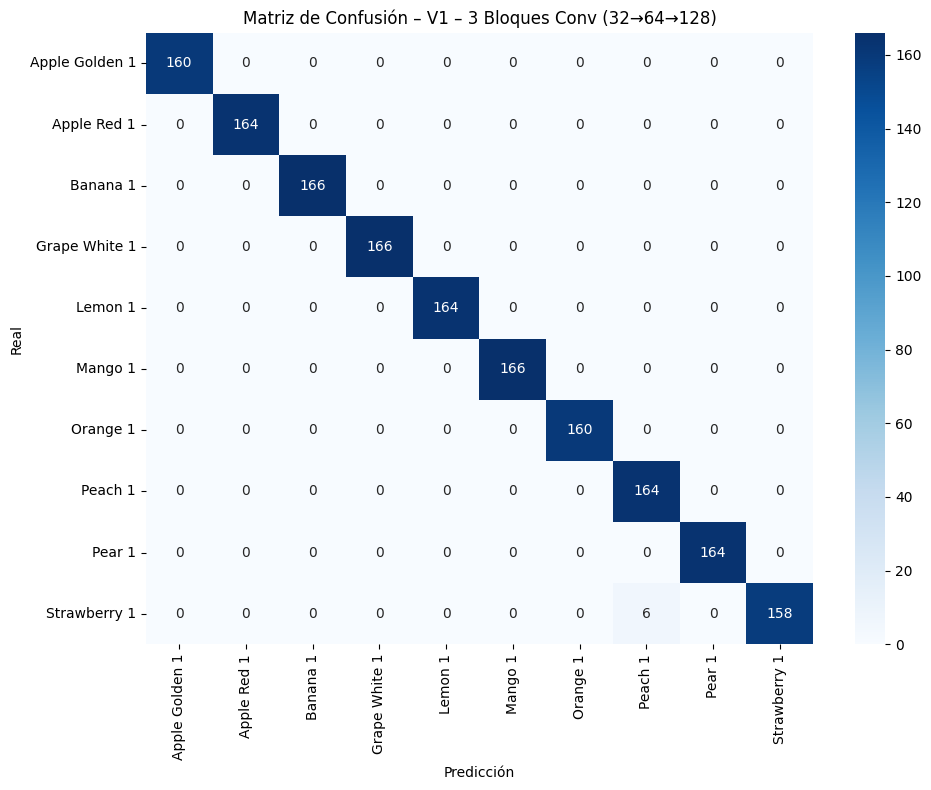

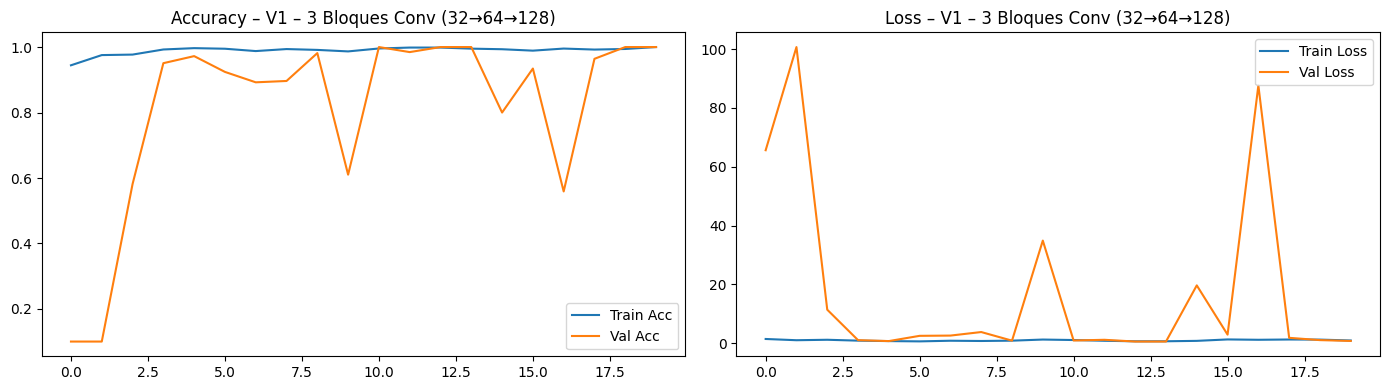

In [6]:
evaluar_modelo(model_v1, history_v1, test_data, class_labels,
               nombre_variacion='V1 – 3 Bloques Conv (32→64→128)',
               training_time=training_time_v1)


## Variación 2 – Filtros incrementales + Dropout ligero
Conv 64→128 + Dense (128, 64) + Dropout 0.3 | 25 épocas | LR 0.0005

In [7]:
import warnings; warnings.filterwarnings('ignore')

with tf.device('/GPU:0'):
    model_v2 = models.Sequential([
        layers.Input(shape=(128, 128, 3)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ])
    model_v2.summary()
    model_v2.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy', metrics=['accuracy']
    )
    start_time = time.time()
    history_v2 = model_v2.fit(train_data, validation_data=val_data, epochs=25)
    training_time_v2 = time.time() - start_time
    print(f'Tiempo V2: {training_time_v2:.2f}s')


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 126, 126, 64)      1792      
                                                                 
 batch_normalization_3 (Batc  (None, 126, 126, 64)     256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 63, 63, 64)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 61, 61, 128)       73856     
                                                                 
 batch_normalization_4 (Batc  (None, 61, 61, 128)      512       
 hNormalization)                                                 
                                                      

        V2 – Filtros 64→128 + Dropout 0.3         
Accuracy (test):          0.9505
Loss (test):              0.9768
Val Accuracy:             0.9395
Val Loss:                 1.2144
Tiempo entreno:           14417.00s
--------------------------------------------------
                 HIPERPARÁMETROS                  
--------------------------------------------------
Batch Size:               32
Learning Rate:            0.0005000000237487257
Optimizer:                Adam
Regularización L2:        0.0010000000474974513
Dropout:                  0.3

Reporte de clasificación:
                precision    recall  f1-score   support

Apple Golden 1       1.00      0.82      0.90       160
   Apple Red 1       1.00      1.00      1.00       164
      Banana 1       1.00      0.83      0.91       166
 Grape White 1       1.00      1.00      1.00       166
       Lemon 1       0.96      1.00      0.98       164
       Mango 1       0.89      1.00      0.94       166
      Orange 1       0

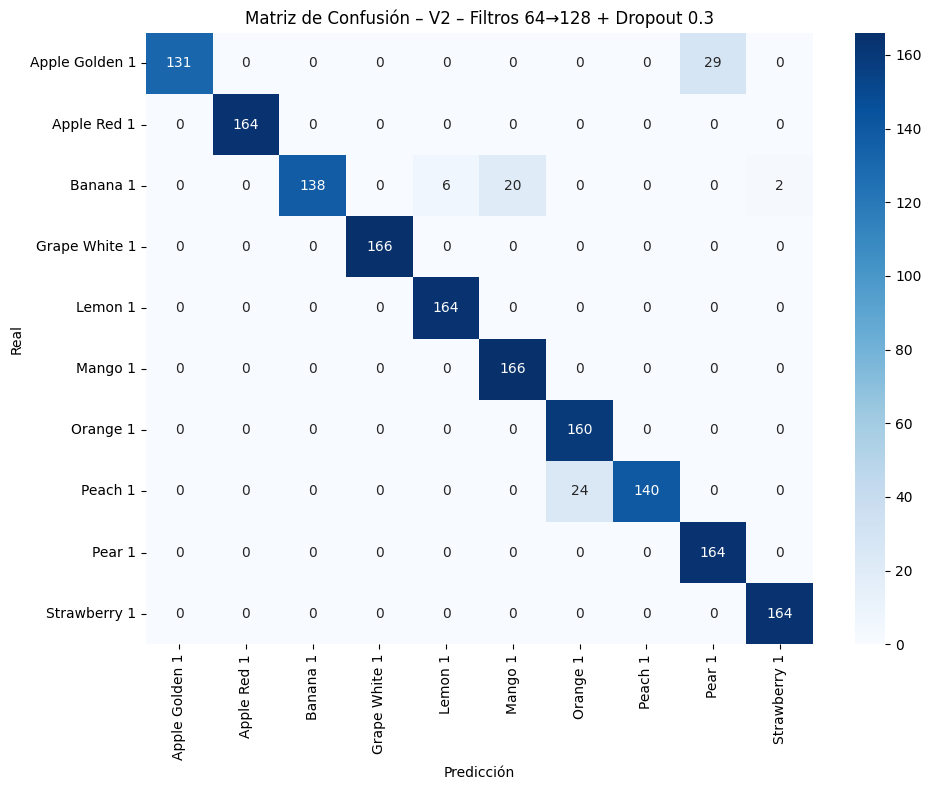

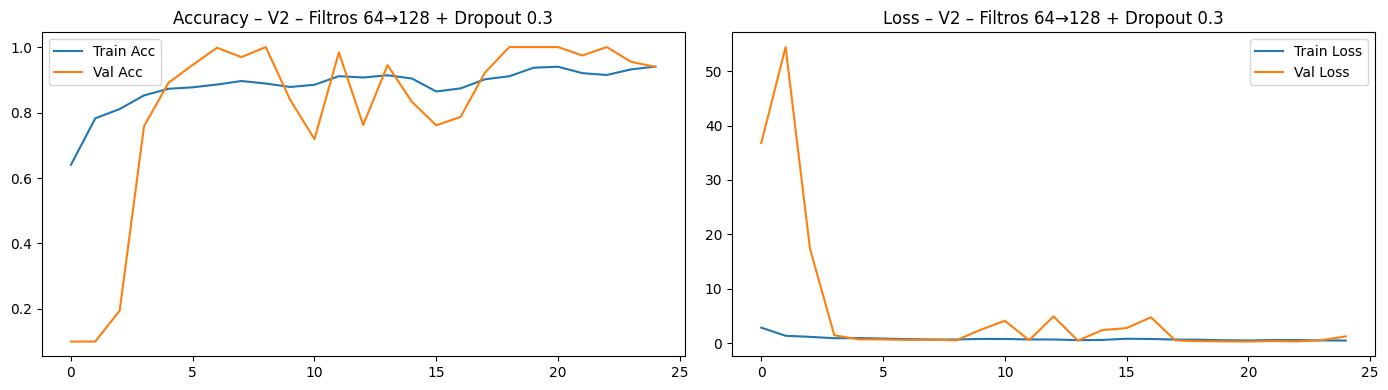

In [8]:
evaluar_modelo(model_v2, history_v2, test_data, class_labels,
               nombre_variacion='V2 – Filtros 64→128 + Dropout 0.3',
               training_time=training_time_v2)


## Variación 3 – Data Augmentation
Rotación 15°, zoom 10%, flip horizontal | 20 épocas | LR 0.001

In [9]:
import warnings; warnings.filterwarnings('ignore')

aug_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=val_split,
    rotation_range=15, zoom_range=0.1, horizontal_flip=True
)
train_data_v3, val_data_v3 = make_generators(aug_datagen)

with tf.device('/GPU:0'):
    model_v3 = models.Sequential([
        layers.Input(shape=(128, 128, 3)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ])
    model_v3.summary()
    model_v3.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy', metrics=['accuracy']
    )
    start_time = time.time()
    history_v3 = model_v3.fit(train_data_v3, validation_data=val_data_v3, epochs=20)
    training_time_v3 = time.time() - start_time
    print(f'Tiempo V3: {training_time_v3:.2f}s')


Found 3914 images belonging to 10 classes.
Found 975 images belonging to 10 classes.
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 batch_normalization_5 (Batc  (None, 126, 126, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_6 (Batc  (None, 61, 61, 64)       256       
 hNormalization)                   

              V3 – Data Augmentation              
Accuracy (test):          0.9786
Loss (test):              1.1620
Val Accuracy:             0.9877
Val Loss:                 1.0965
Tiempo entreno:           998.91s
--------------------------------------------------
                 HIPERPARÁMETROS                  
--------------------------------------------------
Batch Size:               32
Learning Rate:            0.0010000000474974513
Optimizer:                Adam
Regularización L2:        0.0010000000474974513
Dropout:                  0.4

Reporte de clasificación:
                precision    recall  f1-score   support

Apple Golden 1       1.00      1.00      1.00       160
   Apple Red 1       1.00      1.00      1.00       164
      Banana 1       1.00      0.79      0.88       166
 Grape White 1       1.00      1.00      1.00       166
       Lemon 1       0.82      1.00      0.90       164
       Mango 1       1.00      1.00      1.00       166
      Orange 1       1.0

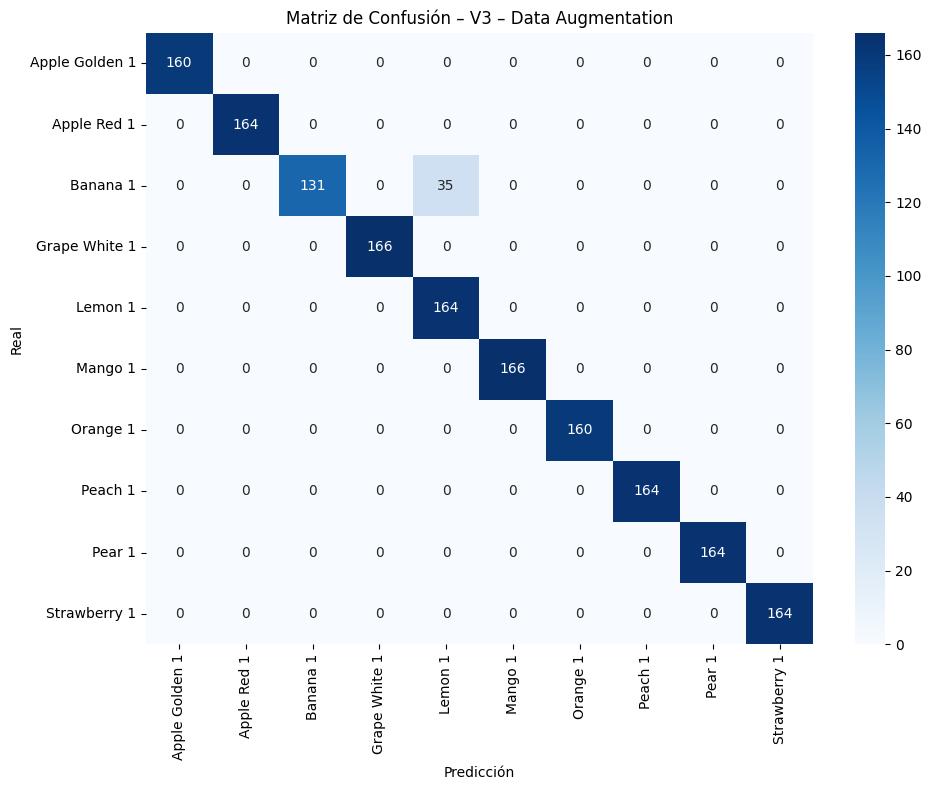

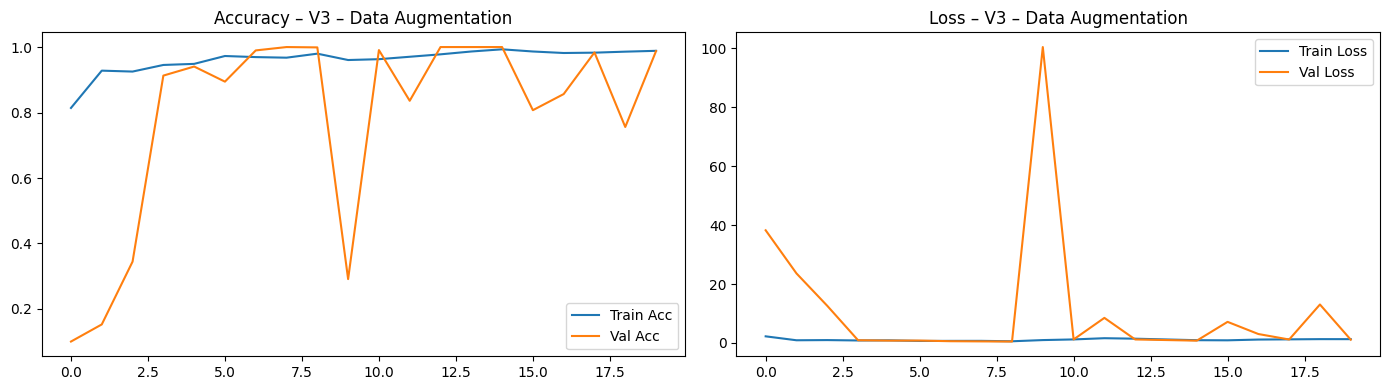

In [10]:
evaluar_modelo(model_v3, history_v3, test_data, class_labels,
               nombre_variacion='V3 – Data Augmentation',
               training_time=training_time_v3)


## Variación 4 – Learning Rate Schedule
ReduceLROnPlateau (factor=0.5, patience=3) | 30 épocas | LR inicial 0.001

In [11]:
import warnings; warnings.filterwarnings('ignore')

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

with tf.device('/GPU:0'):
    model_v4 = models.Sequential([
        layers.Input(shape=(128, 128, 3)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ])
    model_v4.summary()
    model_v4.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy', metrics=['accuracy']
    )
    start_time = time.time()
    history_v4 = model_v4.fit(
        train_data, validation_data=val_data,
        epochs=30, callbacks=[lr_scheduler]
    )
    training_time_v4 = time.time() - start_time
    print(f'Tiempo V4: {training_time_v4:.2f}s')


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 batch_normalization_7 (Batc  (None, 126, 126, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_8 (Batc  (None, 61, 61, 64)       256       
 hNormalization)                                                 
                                                      

       V4 – LR Schedule (ReduceLROnPlateau)       
Accuracy (test):          0.9988
Loss (test):              0.4106
Val Accuracy:             1.0000
Val Loss:                 0.4049
Tiempo entreno:           1522.21s
--------------------------------------------------
                 HIPERPARÁMETROS                  
--------------------------------------------------
Batch Size:               32
Learning Rate:            6.25000029685907e-05
Optimizer:                Adam
Regularización L2:        0.0010000000474974513
Dropout:                  0.4

Reporte de clasificación:
                precision    recall  f1-score   support

Apple Golden 1       0.99      1.00      0.99       160
   Apple Red 1       1.00      1.00      1.00       164
      Banana 1       1.00      1.00      1.00       166
 Grape White 1       1.00      1.00      1.00       166
       Lemon 1       1.00      1.00      1.00       164
       Mango 1       1.00      1.00      1.00       166
      Orange 1       1.0

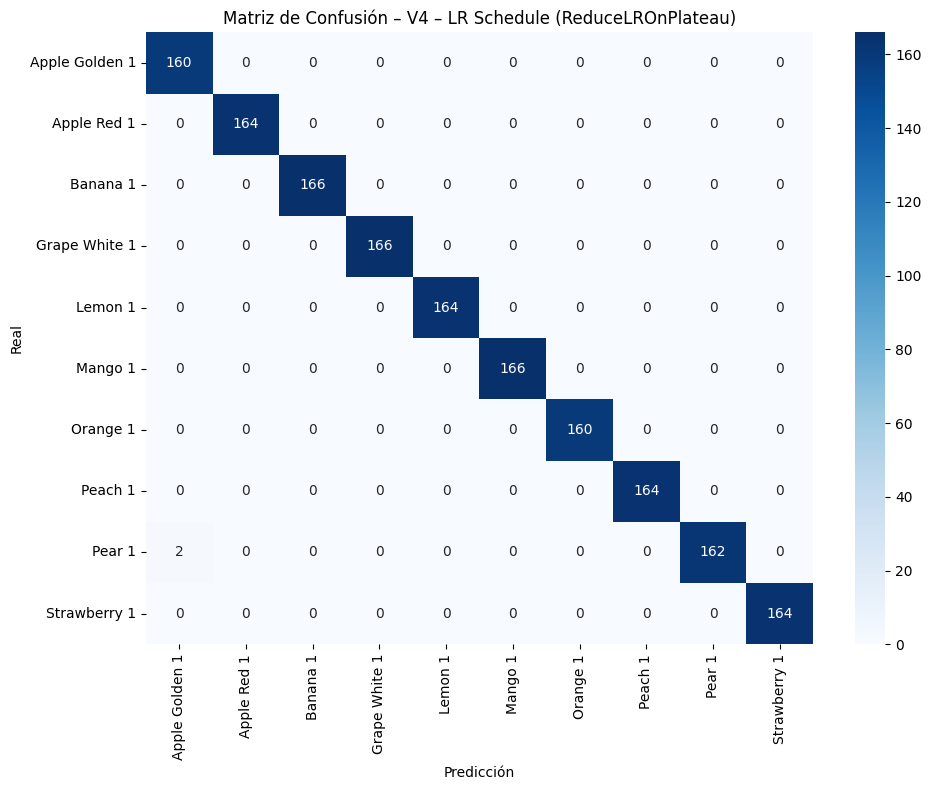

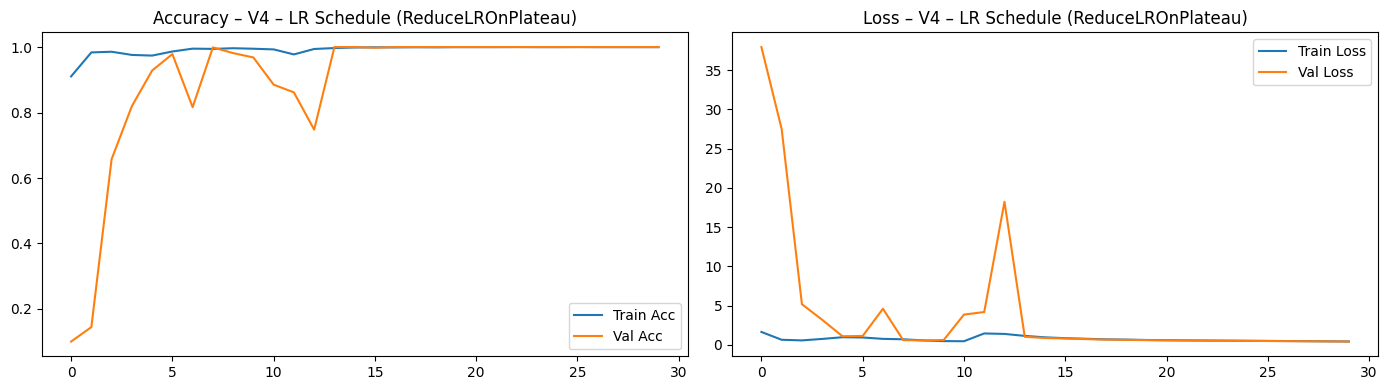

In [12]:
evaluar_modelo(model_v4, history_v4, test_data, class_labels,
               nombre_variacion='V4 – LR Schedule (ReduceLROnPlateau)',
               training_time=training_time_v4)


## Resumen comparativo

In [13]:
resultados = []
for nombre, model, history, t_time in [
    ('V1 – 3 Bloques Conv',    model_v1, history_v1, training_time_v1),
    ('V2 – Filtros 64→128',    model_v2, history_v2, training_time_v2),
    ('V3 – Augmentation',      model_v3, history_v3, training_time_v3),
    ('V4 – LR Schedule',       model_v4, history_v4, training_time_v4),
]:
    tl, ta = model.evaluate(test_data, verbose=0)
    resultados.append({
        'Variación':        nombre,
        'Test Acc':         f'{ta:.4f}',
        'Test Loss':        f'{tl:.4f}',
        'Val Acc (última)': f"{history.history['val_accuracy'][-1]:.4f}",
        'Tiempo (s)':       f'{t_time:.1f}'
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))


          Variación Test Acc Test Loss Val Acc (última) Tiempo (s)
V1 – 3 Bloques Conv   0.9963    0.7650           1.0000     1530.4
V2 – Filtros 64→128   0.9505    0.9768           0.9395    14417.0
  V3 – Augmentation   0.9786    1.1620           0.9877      998.9
   V4 – LR Schedule   0.9988    0.4106           1.0000     1522.2
